# 01 — Data & Universe

**Dynamic Asset Allocation — Financial Markets Analytics 2025/26 (Prof. G. Forte)**

## Research question (context)

> *Do the lessons of past crises carry over? Does robust dynamic asset allocation (Michaud resampling, Black–Litterman) earn its value primarily in crisis and post-crisis regimes — and do "crisis hedge" assets (long Treasuries, gold, TIPS) deserve their place in the universe once estimation error is handled properly?*

This secondary question is not the pivot of the project (which remains the out-of-sample comparison of Markowitz, Michaud and Black–Litterman), but it gives context to two design choices made in this notebook: **which assets** we include and **which sample period** we study.

## Universe: 16 US-listed ETFs

Dynamic asset allocation is naturally a multi-asset-class problem, so instead of the single-market stock lists provided (S&P 500 / STOXX 600) we build a broader ETF universe. Each asset is selected for its distinct behaviour in past crises — flight-to-quality (Treasuries), inflation shocks (TIPS, commodities, gold), credit stress (IG/HY spreads), real assets (REITs):

| Bucket | ETFs | Crisis role |
|---|---|---|
| Equity | SPY, IWM, QQQ, EFA, EEM | return engine; epicentre of 2008/2020 drawdowns |
| Bonds | SHY, IEF, TLT, TIP, LQD, HYG, AGG | flight-to-quality in 2008/2020 — but **failed** in 2022 |
| Alternatives | GLD, DBC, VNQ, BIL | inflation hedges (2022 winners), real estate, cash |

All 16 ETFs have inception ≤ mid-2007, giving **≈ 18.5 years of monthly data (June 2007 – Dec 2025)** — above the 15-year minimum required — and covering three major crises: the GFC (2008), COVID (2020) and the inflation shock (2022).

## Data source

**Yahoo Finance via `yfinance`** (adjusted closes, i.e. total-return: splits and dividends reinvested). Chosen because it is free, reproducible by anyone re-running this notebook, and adequate for monthly ETF series. Known limitations, discussed below: data quality must be checked (we document a cleaning step), and history is bounded by each ETF's inception (which drives the 2007 sample start). Survivorship bias is not a concern for index-tracking ETFs. The risk-free rate is the **3-month T-bill (TB3MS) from FRED**.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from src import config, data, plotting

plotting.setup_style()
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 1. Download

Daily adjusted closes for the 16 tickers (cached to `data/raw/`, set `force=True` to re-download).

In [2]:
daily = data.download_prices()
rf_monthly = data.download_risk_free()
print(f"Daily prices: {daily.shape[0]} days x {daily.shape[1]} ETFs, {daily.index[0]:%Y-%m-%d} -> {daily.index[-1]:%Y-%m-%d}")
daily.tail(3)

Daily prices: 4676 days x 16 ETFs, 2007-06-01 -> 2025-12-30


Ticker,SPY,IWM,QQQ,EFA,EEM,SHY,IEF,TLT,TIP,LQD,HYG,AGG,GLD,DBC,VNQ,BIL
Date,,,,,,,,,,,,,,,,
2025-12-26,686.6609,250.3781,622.4203,95.0656,54.5166,81.5941,94.9035,86.1320,108.4380,108.5953,78.6482,98.4070,416.7400,22.7000,87.1520,90.0526
2025-12-29,684.2139,248.8445,619.4074,94.7802,54.3774,81.6335,95.0412,86.4559,108.5365,108.7426,78.6775,98.5250,398.6000,22.4900,87.3285,90.0526
2025-12-30,683.3784,247.0022,617.9708,94.9377,54.5962,81.6532,94.9428,86.2498,108.5168,108.6150,78.7556,98.4857,398.8900,22.6400,87.5051,90.0624


## 2. Preliminary inspection & documented cleaning step

Per ticker we check: first/last observation, missing values *inside* the traded history, non-positive prices, and extreme daily returns (|r| > 20%, verified against known events rather than silently removed).

In [3]:
qc = data.quality_report(daily)
config.DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
qc.to_csv(config.DATA_PROCESSED / "data_quality_report.csv")
qc

,first_obs,last_obs,n_obs,n_missing_inside,n_zero_price,max_abs_daily_ret,n_daily_ret_gt_20pct
ticker,,,,,,,
SPY,2007-06-01,2025-12-30,4676,0,0,0.1452,0
IWM,2007-06-01,2025-12-30,4676,0,0,0.1327,0
QQQ,2007-06-01,2025-12-30,4676,0,0,0.1216,0
EFA,2007-06-01,2025-12-30,4676,0,0,0.1589,0
EEM,2007-06-01,2025-12-30,4676,0,0,0.2277,2
SHY,2007-06-01,2025-12-30,4676,0,0,0.0100,0
IEF,2007-06-01,2025-12-30,4676,0,0,0.0343,0
TLT,2007-06-01,2025-12-30,4676,0,0,0.0752,0
TIP,2007-06-01,2025-12-30,4676,0,0,0.0445,0


**Cleaning decisions** (documented as required by the assignment):

1. **Missing values inside the history** (exchange holidays / provider gaps): forward-filled with a 5-day limit *before* the month-end resample — a month-end price is never carried across months.
2. **Common sample**: the monthly panel starts at the first month-end where **all 16 ETFs** trade, so every strategy sees the same universe (no changing asset menu mid-backtest).
3. **Extreme returns** are inspected, not removed: legitimate crisis moves (e.g. late 2008) must stay in the sample — they are exactly what the research question is about.
4. **Monthly frequency**: month-end prices → simple returns for the backtest (log returns only for descriptive statistics).

In [4]:
monthly, returns, rf = data.load_dataset()
print(f"Monthly panel: {monthly.shape[0]} month-ends, {monthly.index[0]:%Y-%m} -> {monthly.index[-1]:%Y-%m}")
print(f"Monthly returns: {returns.shape[0]} obs ({returns.shape[0]/12:.1f} years) — assignment minimum is 15 years")
assert returns.isna().sum().sum() == 0, "clean panel must have no NaNs"
assert (monthly > 0).all().all(), "prices must be strictly positive"
returns.tail(3)

Monthly panel: 223 month-ends, 2007-06 -> 2025-12
Monthly returns: 222 obs (18.5 years) — assignment minimum is 15 years


Ticker,SPY,IWM,QQQ,EFA,EEM,SHY,IEF,TLT,TIP,LQD,HYG,AGG,GLD,DBC,VNQ,BIL
Date,,,,,,,,,,,,,,,,
2025-10-31,0.0238,0.0176,0.0478,0.0120,0.0356,0.0033,0.0071,0.0138,0.0032,0.0015,-0.0001,0.0062,0.0356,0.0155,-0.0245,0.0035
2025-11-30,0.0020,0.0102,-0.0156,0.0074,-0.0177,0.0044,0.0099,0.0027,0.0022,0.0093,0.0075,0.0061,0.0537,0.0079,0.0242,0.0029
2025-12-31,0.0083,0.0004,0.0016,0.0315,0.0248,0.0033,-0.0043,-0.0188,-0.0042,-0.0031,0.0059,-0.0004,0.0284,0.0148,-0.0143,0.0032


## 3. Descriptive statistics

In [5]:
from scipy import stats as scistats

desc = pd.DataFrame({
    "bucket": [config.UNIVERSE[t][0] for t in returns.columns],
    "ann. return": (1 + returns).prod() ** (12 / len(returns)) - 1,
    "ann. vol": returns.std() * np.sqrt(12),
    "skew": returns.skew(),
    "ex. kurtosis": returns.kurtosis(),
    "worst month": returns.min(),
    "best month": returns.max(),
    "max drawdown": ((1 + returns).cumprod() / (1 + returns).cumprod().cummax() - 1).min(),
})
desc.to_csv(config.DATA_PROCESSED / "descriptive_stats.csv")
desc.sort_values(["bucket", "ann. vol"])

,bucket,ann. return,ann. vol,skew,ex. kurtosis,worst month,best month,max drawdown
Ticker,,,,,,,,
BIL,alternative,0.0129,0.0055,1.0190,-0.2454,-0.0023,0.0051,-0.0042
GLD,alternative,0.1037,0.1701,-0.0193,0.2400,-0.1614,0.1279,-0.4291
DBC,alternative,0.0044,0.1867,-0.6774,2.1415,-0.2508,0.1627,-0.7455
VNQ,alternative,0.0556,0.2239,-0.5932,5.2995,-0.3173,0.3068,-0.6463
SHY,bond,0.0184,0.0153,0.4604,2.1695,-0.0140,0.0179,-0.0536
AGG,bond,0.0317,0.0465,0.2647,2.9821,-0.0415,0.0666,-0.1713
TIP,bond,0.0356,0.0586,-0.5796,4.3842,-0.0809,0.0650,-0.1391
IEF,bond,0.0348,0.0675,0.1660,0.6998,-0.0474,0.0775,-0.2315
LQD,bond,0.0431,0.0834,0.2003,6.1359,-0.1073,0.1381,-0.2326


Negative skew and fat tails concentrate in equity, HY credit and REITs — the crisis-sensitive assets. Treasuries and gold show the mildest drawdowns: the raw material of the "crisis hedge" story we test in notebook 04.

## 4. Correlation structure

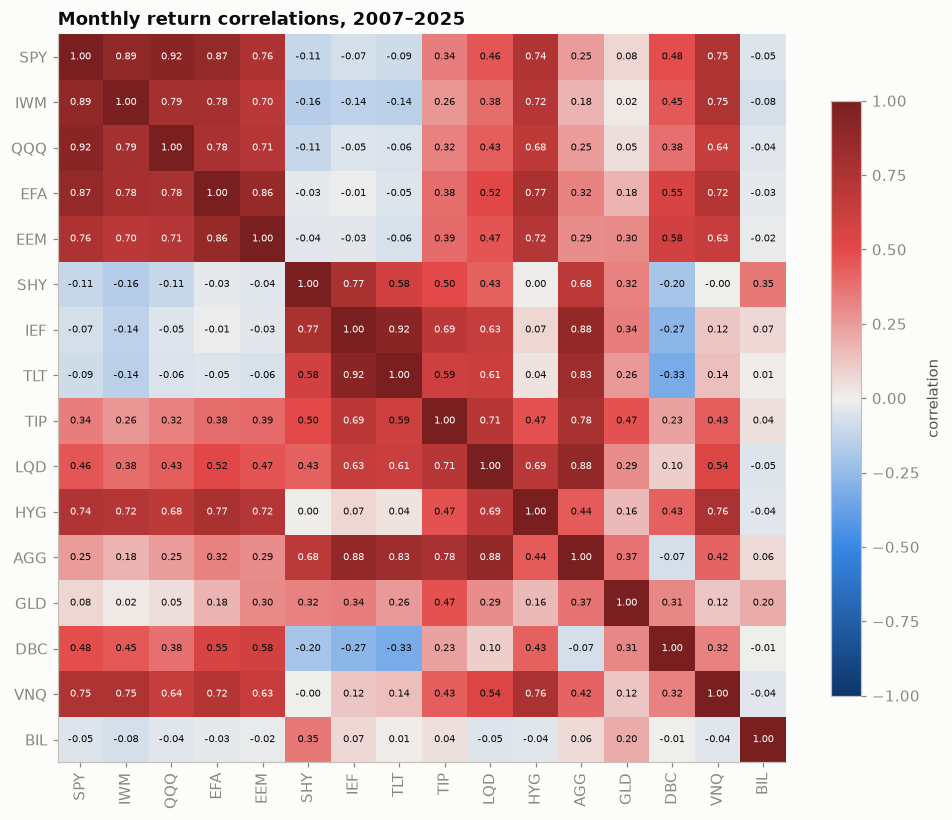

In [6]:
corr = returns.corr()

diverging = mpl.colors.LinearSegmentedColormap.from_list(
    "bl_rd", ["#0d366b", "#3987e5", "#f0efec", "#e34948", "#7a1f1f"])
fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(corr.values, cmap=diverging, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=90)
ax.set_yticks(range(len(corr)), corr.columns)
ax.grid(False)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6.5,
                color="white" if abs(v) > 0.6 else "#0b0b0b")
fig.colorbar(im, ax=ax, shrink=0.8, label="correlation")
ax.set_title("Monthly return correlations, 2007–2025", loc="left")
fig.tight_layout()
plotting.savefig(fig, "01_correlation_heatmap")
plt.show()

Three blocks emerge: an equity/HY/REIT block (ρ ≈ 0.7–0.9), a Treasury duration block, and gold/commodities weakly correlated with both — the diversification potential the optimisers will try to exploit.

**But correlations are not stable.** The equity–bond correlation is the hinge of every 60/40-style allocation, and it flipped sign in 2022:

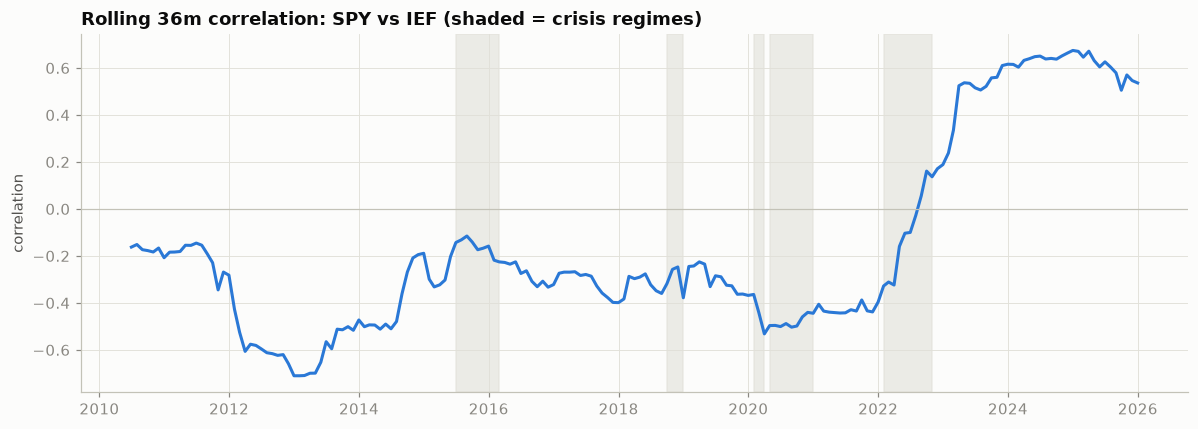

In [7]:
roll_corr = returns["SPY"].rolling(36).corr(returns["IEF"])

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(roll_corr.index, roll_corr.values, color="#2a78d6", lw=2)
ax.axhline(0, color="#c3c2b7", lw=0.8)
for name, (start, end) in config.REGIMES.items():
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color="#e1e0d9", alpha=0.6)
ax.set_title("Rolling 36m correlation: SPY vs IEF (shaded = crisis regimes)", loc="left")
ax.set_ylabel("correlation")
fig.tight_layout()
plotting.savefig(fig, "01_rolling_corr_spy_ief")
plt.show()

## 5. The crises in the sample

Normalised performance of one representative asset per bucket, with the ex-ante crisis regimes shaded. This is the visual motivation for the universe: **different crises were hedged by different assets** (Treasuries in 2008/2020, commodities and gold in 2022 — when Treasuries *lost* money).

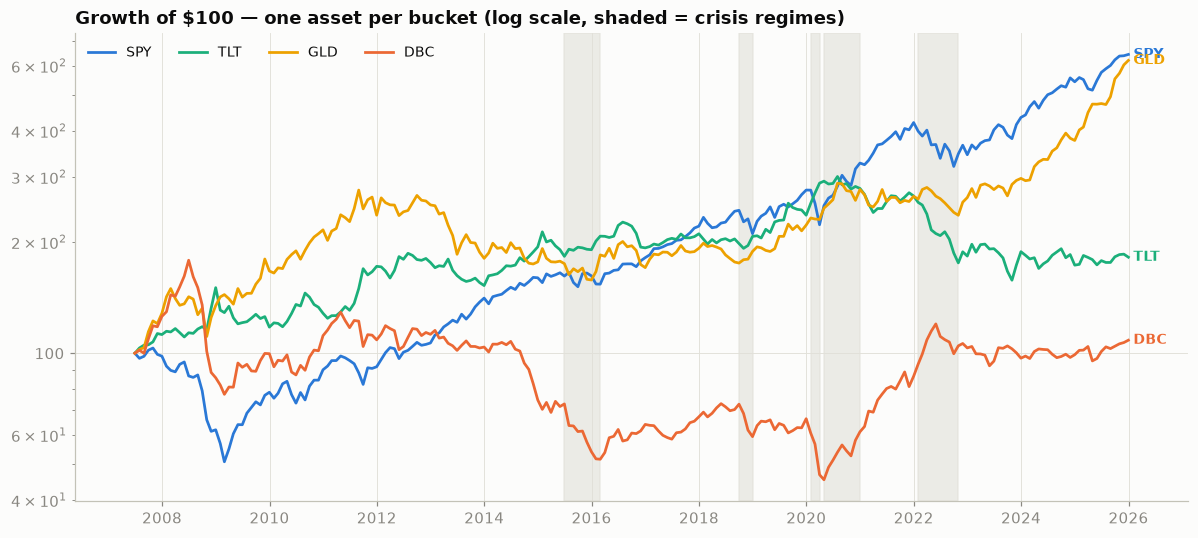

In [8]:
representatives = {"SPY": "#2a78d6", "TLT": "#1baf7a", "GLD": "#eda100", "DBC": "#eb6834"}
norm = monthly[list(representatives)] / monthly[list(representatives)].iloc[0] * 100

fig, ax = plt.subplots(figsize=(11, 5))
for t, c in representatives.items():
    ax.plot(norm.index, norm[t], color=c, lw=1.8, label=t)
    ax.annotate(f" {t}", xy=(norm.index[-1], norm[t].iloc[-1]), color=c,
                fontsize=9, fontweight="bold", va="center")
for name, (start, end) in config.REGIMES.items():
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color="#e1e0d9", alpha=0.6)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mpl.ticker.ScalarFormatter())
ax.set_title("Growth of $100 — one asset per bucket (log scale, shaded = crisis regimes)", loc="left")
ax.legend(loc="upper left", ncols=4, fontsize=9)
ax.margins(x=0.06)
fig.tight_layout()
plotting.savefig(fig, "01_crises_by_asset")
plt.show()

## Takeaways

1. Clean 16-asset monthly panel, **2007-06 → 2025-12** (~18.5y ≥ 15y minimum), cached in `data/processed/`; QC table saved alongside.
2. The universe spans genuinely heterogeneous crisis behaviour — correlations between blocks are low *on average* but **regime-dependent** (SPY–IEF flipped positive in 2022).
3. This instability of the inputs (μ, Σ) is exactly the estimation-error problem that motivates comparing classical Markowitz with Michaud resampling and Black–Litterman → **notebook 02**.